# ENSF 444 Project

In [42]:
# Importing all required modules
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

### Loading the Dataset

In [43]:
df = pd.read_csv("airbnb_calgary.csv") # Reading the dataset
df.head() # Displaying the first few rows of the dataset

,Country,Location,Airbnb_ListingID,Scrape_Date,Lat,Lng,City,LocalizedCity,LocalizedNeighbourhood_Source,LocalizedNeighbourhood_ML,...,BasicNightPrice,Taxes,BasicNightPriceString_USD,BasicNightPrice_USD,Taxes_USD,isOverpricedPerBeds_Calc,isOverpricedPerGuest_Calc,Amenities_SelfCheckIn,HostLanguages_Verbose,RecordInserted
0,Canada,Calgary,937715569409099752,2025-10-29,51.04095,-114.05496,Calgary,Calgary,Beltline,Beltline,...,NaN,NaN,NaN,NaN,NaN,0,0,True,['English'],2025-10-29 18:17:30
1,Canada,Calgary,32673090,2025-10-29,51.04100,-114.07015,Calgary,Calgary,Beltline,Beltline,...,NaN,NaN,NaN,NaN,NaN,0,0,False,[],2025-10-29 18:17:36
2,Canada,Calgary,21531279,2025-10-29,51.04938,-114.08603,Calgary,Calgary,Downtown Calgary,Downtown Calgary,...,NaN,NaN,NaN,NaN,NaN,0,0,True,['English'],2025-10-29 18:17:58
3,Canada,Calgary,43868185,2025-10-29,51.15801,-113.96024,Calgary,Calgary,Skyview Ranch,Skyview Ranch,...,414.00,181.21,5 nights x $297.04,297.0,130.0,1,0,True,['English' 'French' 'Tagalog'],2025-10-29 18:20:00
4,Canada,Calgary,1435646668154816977,2025-10-29,50.97939,-114.06274,Calgary,Calgary,Acadia,NaN,...,246.73,104.55,5 nights x $177.50,177.0,75.0,0,0,True,[],2025-10-29 18:21:58


### Pre-processing (data cleaning)

In [44]:
df = df.drop(columns=["Airbnb_ListingID", "HostLanguages_Verbose"], errors='ignore')
df = df.fillna(df.median(numeric_only=True))
df = df.fillna("Unknown")

Q1 = df["BasicNightPrice_USD"].quantile(0.25)
Q3 = df["BasicNightPrice_USD"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["BasicNightPrice_USD"] >= Q1 - 1.5*IQR) & (df["BasicNightPrice_USD"] <= Q3 + 1.5*IQR)]

df.head()

,Country,Location,Scrape_Date,Lat,Lng,City,LocalizedCity,LocalizedNeighbourhood_Source,LocalizedNeighbourhood_ML,LocalizedNeighbourhood,...,Currency,BasicNightPrice,Taxes,BasicNightPriceString_USD,BasicNightPrice_USD,Taxes_USD,isOverpricedPerBeds_Calc,isOverpricedPerGuest_Calc,Amenities_SelfCheckIn,RecordInserted
0,Canada,Calgary,2025-10-29,51.04095,-114.05496,Calgary,Calgary,Beltline,Beltline,Beltline,...,CAD,133.82,54.36,Unknown,96.0,39.0,0,0,True,2025-10-29 18:17:30
1,Canada,Calgary,2025-10-29,51.04100,-114.07015,Calgary,Calgary,Beltline,Beltline,Beltline,...,CAD,133.82,54.36,Unknown,96.0,39.0,0,0,False,2025-10-29 18:17:36
2,Canada,Calgary,2025-10-29,51.04938,-114.08603,Calgary,Calgary,Downtown Calgary,Downtown Calgary,Downtown Calgary,...,CAD,133.82,54.36,Unknown,96.0,39.0,0,0,True,2025-10-29 18:17:58
4,Canada,Calgary,2025-10-29,50.97939,-114.06274,Calgary,Calgary,Acadia,Unknown,Acadia,...,CAD,246.73,104.55,5 nights x $177.50,177.0,75.0,0,0,True,2025-10-29 18:21:58
5,Canada,Calgary,2025-10-29,50.86792,-113.95509,Calgary,Calgary,Seton,Seton,Seton,...,CAD,117.09,52.97,5 nights x $84.50,84.0,38.0,0,0,True,2025-10-29 18:23:04


### Next Section

In [45]:
df = pd.get_dummies(df, drop_first=True)

In [46]:
X = df.drop("BasicNightPrice_USD", axis=1)
y = df["BasicNightPrice_USD"]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Training the models

info here

In [49]:

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


### Model Comparisons

In [52]:
def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    return mae, rmse, r2

In [53]:
lr_results = evaluate(lr, X_test_scaled, y_test)
rf_results = evaluate(rf, X_test, y_test)
gb_results = evaluate(gb, X_test, y_test)

In [55]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [lr_results[0], rf_results[0], gb_results[0]],
    "RMSE": [lr_results[1], rf_results[1], gb_results[1]],
    "R2": [lr_results[2], rf_results[2], gb_results[2]]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,10.992563,14.863256,0.833506
1,Random Forest,0.007934,0.067003,0.999997
2,Gradient Boosting,0.146957,0.225887,0.999962


### Visualization

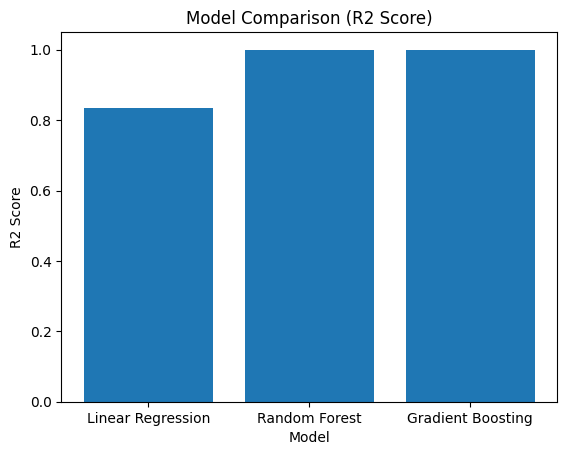

In [57]:
plt.bar(results["Model"], results["R2"])
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.show()